<a href="https://colab.research.google.com/github/erigitola/-Random-User--Generator--using--API/blob/main/Financial_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd

data = {
    "date": ["2026-01-01","2026-01-01","2026-01-02","2026-01-02","2026-01-03",
             "2026-01-03","2026-01-04","2026-01-04","2026-01-05","2026-01-05"],

    "transaction_id": ["T001","T002","T003","T004","T005","T006","T007","T008","T009","T010"],

    "type": ["Income","Expense","Income","Expense","Income",
             "Expense","Income","Expense","Income","Expense"],

    "category": ["Sales","Transport","Sales","Utilities","Sales",
                 "Supplies","Sales","Maintenance","Sales","Rent"],

    "amount": [55000,12000,43000,15000,60000,18000,52000,22000,48000,30000]
}

df = pd.DataFrame(data)
df


,date,transaction_id,type,category,amount
0,2026-01-01,T001,Income,Sales,55000
1,2026-01-01,T002,Expense,Transport,12000
2,2026-01-02,T003,Income,Sales,43000
3,2026-01-02,T004,Expense,Utilities,15000
4,2026-01-03,T005,Income,Sales,60000
5,2026-01-03,T006,Expense,Supplies,18000
6,2026-01-04,T007,Income,Sales,52000
7,2026-01-04,T008,Expense,Maintenance,22000
8,2026-01-05,T009,Income,Sales,48000
9,2026-01-05,T010,Expense,Rent,30000


In [5]:
# Display first 5 rows
df.head()

,date,transaction_id,type,category,amount
0,2026-01-01,T001,Income,Sales,55000
1,2026-01-01,T002,Expense,Transport,12000
2,2026-01-02,T003,Income,Sales,43000
3,2026-01-02,T004,Expense,Utilities,15000
4,2026-01-03,T005,Income,Sales,60000


In [6]:
# Display columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            10 non-null     object
 1   transaction_id  10 non-null     object
 2   type            10 non-null     object
 3   category        10 non-null     object
 4   amount          10 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 532.0+ bytes


In [9]:
# Shows rows and columns
df.shape

(10, 5)

In [10]:
# Financial KPIs
df["income"] = df.apply(lambda x: x["amount"] if x["type"] == "Income" else 0, axis=1)
df["expense"] = df.apply(lambda x: x["amount"] if x["type"] == "Expense" else 0, axis=1)

df


,date,transaction_id,type,category,amount,income,expense
0,2026-01-01,T001,Income,Sales,55000,55000,0
1,2026-01-01,T002,Expense,Transport,12000,0,12000
2,2026-01-02,T003,Income,Sales,43000,43000,0
3,2026-01-02,T004,Expense,Utilities,15000,0,15000
4,2026-01-03,T005,Income,Sales,60000,60000,0
5,2026-01-03,T006,Expense,Supplies,18000,0,18000
6,2026-01-04,T007,Income,Sales,52000,52000,0
7,2026-01-04,T008,Expense,Maintenance,22000,0,22000
8,2026-01-05,T009,Income,Sales,48000,48000,0
9,2026-01-05,T010,Expense,Rent,30000,0,30000


In [11]:
# Financial summary
daily_summary = df.groupby("date")[["income","expense"]].sum().reset_index()
daily_summary["profit"] = daily_summary["income"] - daily_summary["expense"]

daily_summary


,date,income,expense,profit
0,2026-01-01,55000,12000,43000
1,2026-01-02,43000,15000,28000
2,2026-01-03,60000,18000,42000
3,2026-01-04,52000,22000,30000
4,2026-01-05,48000,30000,18000


In [13]:
# Financial Summary
daily_summary = df.groupby("date")[["income","expense"]].sum().reset_index()
daily_summary["profit"] = daily_summary["income"] - daily_summary["expense"]

daily_summary


,date,income,expense,profit
0,2026-01-01,55000,12000,43000
1,2026-01-02,43000,15000,28000
2,2026-01-03,60000,18000,42000
3,2026-01-04,52000,22000,30000
4,2026-01-05,48000,30000,18000


In [14]:
# Financial Risk Flag
def financial_status(p):
    if p >= 30000:
        return "Healthy"
    elif p >= 10000:
        return "Moderate"
    else:
        return "Risk"

daily_summary["status"] = daily_summary["profit"].apply(financial_status)

daily_summary


,date,income,expense,profit,status
0,2026-01-01,55000,12000,43000,Healthy
1,2026-01-02,43000,15000,28000,Moderate
2,2026-01-03,60000,18000,42000,Healthy
3,2026-01-04,52000,22000,30000,Healthy
4,2026-01-05,48000,30000,18000,Moderate


In [15]:
# Flag Risk Days
for i in range(len(daily_summary)):
    if daily_summary.loc[i, "status"] == "Risk":
        print("⚠ Risk Day:", daily_summary.loc[i, "date"],
              "| Profit:", daily_summary.loc[i, "profit"])


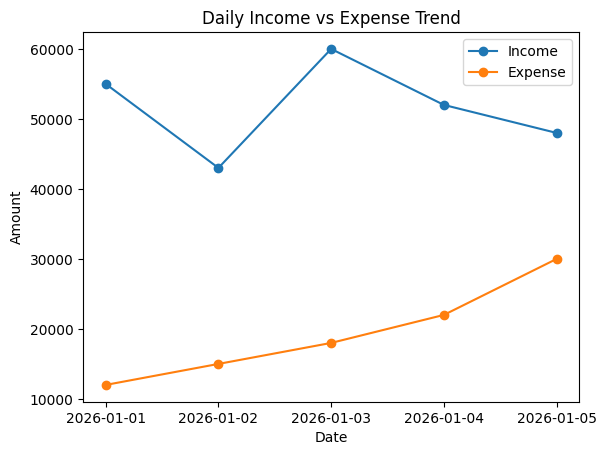

In [16]:


plt.figure()
plt.plot(daily_summary["date"], daily_summary["income"], marker="o", label="Income")
plt.plot(daily_summary["date"], daily_summary["expense"], marker="o", label="Expense")
plt.title("Daily Income vs Expense Trend")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.show()


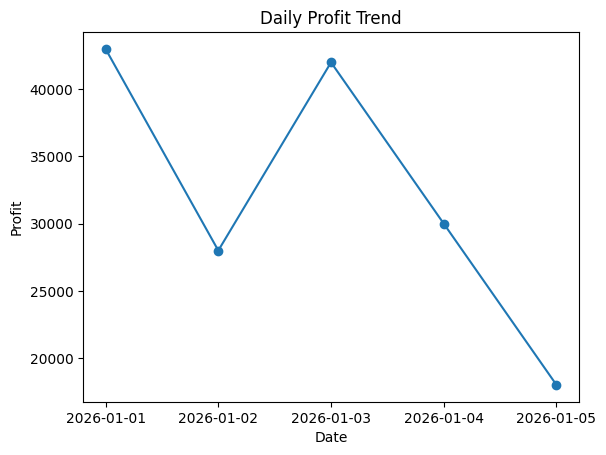

In [17]:
plt.figure()
plt.plot(daily_summary["date"], daily_summary["profit"], marker="o")
plt.title("Daily Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.show()


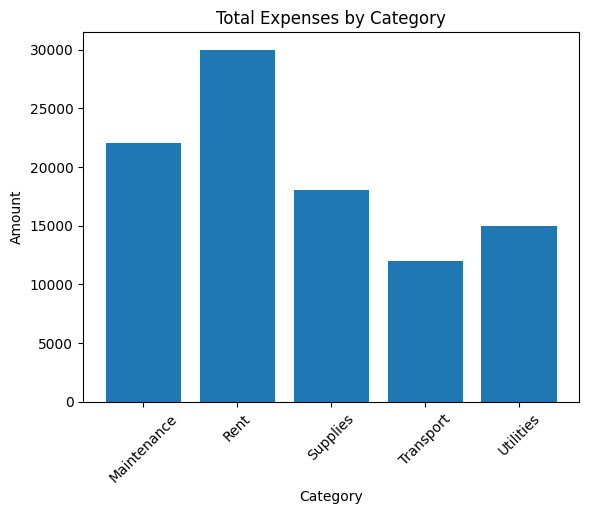

In [18]:
expense_summary = df[df["type"]=="Expense"].groupby("category")["amount"].sum().reset_index()

plt.figure()
plt.bar(expense_summary["category"], expense_summary["amount"])
plt.title("Total Expenses by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=45)
plt.show()


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = daily_summary[["income","expense"]]
y = daily_summary["profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)
predictions


array([28000.])